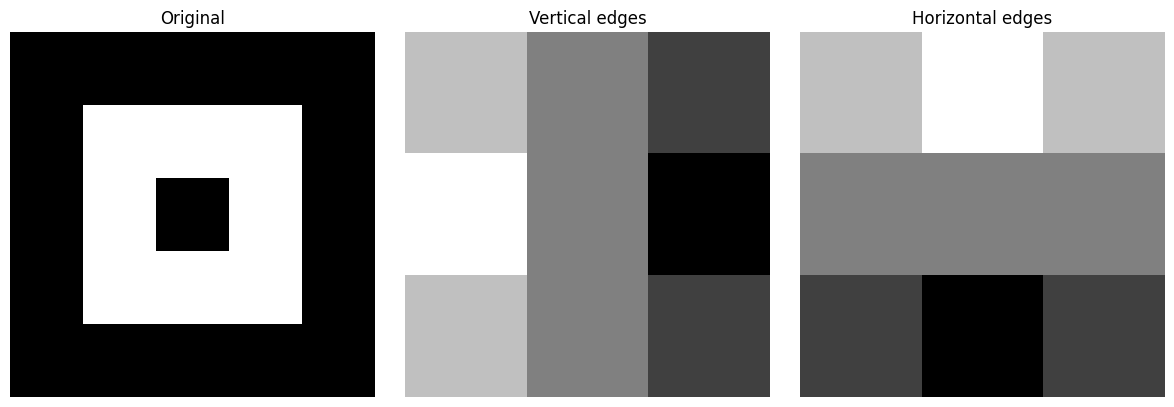

Original shape: (5, 5)
Output shape:   (3, 3)

Vertical edge output:
[[ 1.  0. -1.]
 [ 2.  0. -2.]
 [ 1.  0. -1.]]

Horizontal edge output:
[[ 1.  2.  1.]
 [ 0.  0.  0.]
 [-1. -2. -1.]]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# A tiny 5x5 image
image = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0],
], dtype=float)

# A 3x3 filter — this one detects VERTICAL EDGES
vertical_edge_filter = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])

# A 3x3 filter — this one detects HORIZONTAL EDGES
horizontal_edge_filter = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
])

def convolve2d(image, kernel):
    """
    Slide kernel across image, compute dot product at each position
    """
    ih, iw = image.shape
    kh, kw = kernel.shape
    oh = ih - kh + 1   # output height
    ow = iw - kw + 1   # output width
    output = np.zeros((oh, ow))

    for i in range(oh):
        for j in range(ow):
            # extract patch same size as kernel
            patch = image[i:i+kh, j:j+kw]
            # dot product — one number per position
            output[i, j] = np.sum(patch * kernel)

    return output

# Applying both filters
v_edges = convolve2d(image, vertical_edge_filter)
h_edges = convolve2d(image, horizontal_edge_filter)

# Visualising
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image,   cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(v_edges, cmap='gray'); axes[1].set_title('Vertical edges')
axes[2].imshow(h_edges, cmap='gray'); axes[2].set_title('Horizontal edges')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

print("Original shape:", image.shape)    # (5, 5)
print("Output shape:  ", v_edges.shape)  # (3, 3)
print("\nVertical edge output:")
print(v_edges)
print("\nHorizontal edge output:")
print(h_edges)